# Human Activity Recognition with Wifi

In [14]:
import numpy as np
import numpy.random as rnd
import torch
import matplotlib.pyplot as plt

from models.DopplerDataset import * 
from torch.utils.data import DataLoader
from os import listdir, makedirs, path
from shutil import copy

%load_ext autoreload
%autoreload 2


###############  GLOBAL VARIABLES  #################

PERFORM_DATASET_SEPARATION = True
DATASET_PATH               = "doppler_traces"
TEST_DATASET_FRACTION      = 0.1

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Separating training dataset and test dataset

In [ ]:
train_dataset = DATASET_PATH + "_train"
test_dataset  = DATASET_PATH + "_test"

if PERFORM_DATASET_SEPARATION and (train_dataset not in listdir()) and (test_dataset not in listdir()):
    '''
        Here we split images contained in DATASET_PATH into training dataset and test dataset
    '''
    subdir_list = sorted([name for name in listdir(DATASET_PATH) if path.isdir(DATASET_PATH+'/'+name)])

    # Counting number of images in DATASET_PATH
    img_number = 0
    for subdir in subdir_list:
        img_number += len(listdir(DATASET_PATH+'/'+subdir))
    print(f"Dataset {DATASET_PATH} contains {img_number} images.\nProceding to create training dataset with {int((1-TEST_DATASET_FRACTION)*img_number)} images and test dataset with {int(TEST_DATASET_FRACTION*img_number)} images...\n")

    # Creating train and test datasets
    makedirs(train_dataset, exist_ok=True)
    makedirs(test_dataset, exist_ok=True)

    # Creating a index array to split images into different datasets
    index = np.arange(0, img_number)
    rnd.shuffle(index)
    test_index  = index[:int(img_number*TEST_DATASET_FRACTION)]

    # Moving an image into a training/testing directory with a given probability
    idx = 0
    for subdir in subdir_list:
        for image in sorted(listdir(DATASET_PATH+'/'+subdir)):
            image_path = DATASET_PATH+'/'+subdir+'/'+image
            if idx in test_index:
                copy(image_path, test_dataset)
            else:
                copy(image_path, train_dataset)
            idx += 1

    print("Train and test datasets created successfully!")
else:
    print("Datasets are already splitted!")

## Loading Dataset

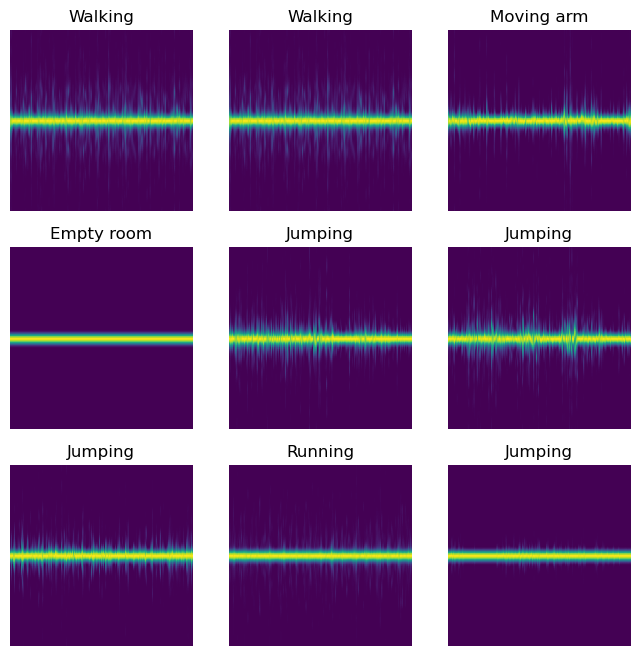

In [19]:
dataset = DopplerDataset("doppler_traces_train")

labels_map = {
    "S": "Standing",
    "W": "Walking",
    "R": "Running",
    "C": "Standing Up",
    "E": "Empty room",
    "L": "Sitting",
    "H": "Moving arm",
    "J": "Jumping"
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols*rows + 1):
    sample_idx = torch.randint(len(dataset), size=(1,)).item()
    img, label = dataset[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img, aspect='auto')
plt.show()